<a href="https://colab.research.google.com/github/siddhigogri/SiddhiGogri_LP_Synapse26/blob/week2_ML/SynapseTask_LP_2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Synapse Week Two**

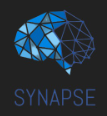



# Synapse Task 2B: SVM & Ensembles

Welcome to Task 2B! In Task 2A, we explored our "individual" baseline classifiers: Logistic Regression, Naive Bayes, and single Decision Trees. You saw firsthand how simple models behave, where their assumptions hold, and how unconstrained trees can run wild with variance.

Now, we level up. In this notebook, we cover **Support Vector Machines (SVM)**—an algorithm that reasons geometrically about margins and hyperplanes—and **Ensemble Methods**, a powerful family of techniques that combine many weak learners into one robust, high-performing model. This notebook closes our classification arc before a dedicated Research Task connecting ensemble techniques back to the Linear Regression you built in Task 1A.

Chalo, let's get building!

## Part 0 — Quick Recap & Rebuild

Before diving into new algorithms, we need our sanitized data ready. We'll reuse the exact same IBM Telco Customer Churn dataset, cleaning steps, and 70:30 train-test split from Task 2A so every comparison remains apples-to-apples.

No new teaching here—just reloading and setting the stage.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Import base libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
# Hint: Reload and clean exactly as in Task 2A — TotalCharges coercion, drop NaNs, drop customerID, encode Churn to 0/1, One-Hot encode nominal features, and perform a 70:30 stratified train-test split
# df = pd.read_csv('/content/drive/MyDrive/.../WA_Fn-UseC_-Telco-Customer-Churn.csv')
# df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# df.dropna(subset=['TotalCharges'], inplace=True)
# df.drop(columns=['customerID'], inplace=True)
# df['Churn'] = (df['Churn'] == 'Yes').astype(int)
# df_encoded = pd.get_dummies(df, drop_first=True)
# X = df_encoded.drop(columns=['Churn'])
# y = df_encoded['Churn']
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## Part 1 — Support Vector Machines & Kernels

While Logistic Regression searches for any decision boundary separating the classes, Support Vector Machines (SVM) search for the **maximum-margin hyperplane**—the line or plane that stays as far away from the closest training samples as mathematically possible. Those critical points hugging the margin edges are called **support vectors**.

The geometric margin width between the two boundary planes is given by:

$$\text{Margin} = \frac{2}{\|w\|}$$

Maximizing this margin is equivalent to minimizing $\frac{1}{2}\|w\|^2$. When classes cannot be separated with a straight cut in the current feature space, SVM deploys the **Kernel Trick**: it maps data points into a higher-dimensional space where a linear boundary *can* slice them apart cleanly, computing inner products without ever explicitly calculating the expensive coordinate transformations.

### Helpful Resources
- [StatQuest: Support Vector Machines Main Idea](https://www.youtube.com/watch?v=efR1C6CvhmE) *(Visual intuition of margins and soft margins)*
- [SVM Formulation & Boundary Intuition](https://www.youtube.com/watch?v=H9yACitf-KM) *(Short video on hyperplanes)*
- [Demystifying Support Vector Machines](https://towardsdatascience.com/demystifying-support-vector-machines-8453b39f7368/) *(Margin geometry and objective setups)*
- [StatQuest: Polynomial Kernel](https://youtu.be/Toet3EiSFcM) *(Watch how higher dimensions untangle points)*
- [StatQuest: The Radial Basis Function (RBF) Kernel](https://youtu.be/Qc5IyLW_hns) *(Visualizing infinite-dimensional projection)*
- [Kernel Feature Map Derivation](https://xavierbourretsicotte.github.io/Kernel_feature_map.html) *(Optional: rigorous inner-product substitution for curious math folks)*
- [Maths Behind SVM](https://www.youtube.com/watch?v=Js3GLb1xPhc) *(Supplementary video walk-through of the optimization setup)*

### Step 1.1: The Kernel Trick in Action (2D Concentric Circles)

To build visual intuition before tackling our high-dimensional churn data, let's create a synthetic 2D dataset using `make_circles`. A linear boundary cannot separate inner and outer rings—let's see what an RBF kernel does.

In [ ]:
# Hint: Generate concentric circles using sklearn.datasets.make_circles
# from sklearn.datasets import make_circles
# X_circ, y_circ =

In [ ]:
# Hint: Fit SVC(kernel='linear') and SVC(kernel='rbf') on (X_circ, y_circ)


In [ ]:
# Hint: Plot both decision boundaries side by side using DecisionBoundaryDisplay
# from sklearn.inspection import DecisionBoundaryDisplay


**Question:** Why does the linear kernel fail completely on this concentric dataset, and what does the RBF kernel do differently to carve out that circular boundary? Explain in plain English without formulas. 🤔  
**Answer:**

### Step 1.2: Feature Scaling for SVM on Telco Data

SVM measures geometric distances to determine margin widths. If one feature is measured in thousands (`TotalCharges`) and another spans 0 to 1, the wider-scale feature will dominate the distance calculations and distort the margin.

In [ ]:
# Hint: Standardize continuous features ['tenure', 'MonthlyCharges', 'TotalCharges']
# from sklearn.preprocessing import StandardScaler
# scaler =
# Remember: fit_transform on X_train, transform on X_test!
# num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
# X_train[num_cols] =
# X_test[num_cols] =

**Question:** Why was standardizing features crucial for SVM here, whereas Decision Trees and Naive Bayes in Task 2A did not care about feature scales at all? 🤔  
**Answer:**

### Step 1.3: Training Support Vector Classifiers on Telco Churn

Now let's apply `SVC` to our real churn dataset across three distinct kernels: `linear`, `rbf`, and `poly`.

In [ ]:
# Hint: Loop through kernels ['linear', 'rbf', 'poly'], fit SVC(kernel=k, random_state=42) on X_train/y_train,
# and print the test accuracy for each
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score


**Question:** Can you name one real-world production use case outside churn prediction where Support Vector Machines are preferred over other classifiers? 🤔  
**Answer:**

## Part 2 — Why Combine Models? (Bias-Variance, Revisited)

In Task 2A, you plotted tree depth versus error and uncovered the fundamental tug-of-war in supervised learning: shallow trees suffer from high bias (underfitting), while deep unconstrained trees suffer from high variance (overfitting).

Ensemble learning offers a way to push past that trade-off by combining multiple models:
- **Bagging (Bootstrap Aggregating):** Trains multiple high-variance, deep models in parallel on random slices of the data, then averages their predictions. Averaging decorrelated predictions slashes variance without increasing bias.
- **Boosting:** Chains multiple high-bias, shallow models sequentially. Each new model focuses its learning capacity on the samples misclassified by preceding rounds, systematically reducing bias.

### Helpful Resources
- [Bagging vs. Boosting: Deep Dive for Tree-Based Models](https://medium.com/data-science-collective/bagging-vs-boosting-a-deep-dive-into-ensemble-learning-for-tree-based-models-b3a061da3e62) *(Ties ensemble strategies directly to Task 2A's bias-variance curves)*
- [How Gradient Boosting Actually Works Under the Hood](https://letsdatascience.com/blog/how-gradient-boosting-actually-works-under-the-hood-building-it-from-scratch-in-python) *(Step-by-step intuition)*

**Question:** In your own words, why does averaging the predictions of many overfit, high-variance decision trees tend to cancel out their individual overfitting? 🤔  
**Answer:**

## Part 3 — Bagging & Random Forest

A single decision tree is sensitive: small tweaks to the training data can yield an entirely different tree structure. **Bagging** stabilizes this by drawing bootstrap samples (random sampling with replacement), training an independent tree on each, and aggregating votes.

**Random Forest** adds a crucial enhancement: whenever a tree considers a split, it is restricted to a random subset of features (typically $\sqrt{p}$). This prevents a few dominant features from dictating every tree, ensuring the ensemble is populated by diverse, decorrelated learners.

### Helpful Resources
- [Ensemble Learning: Bagging Explained](https://www.youtube.com/watch?v=KIOeZ5cFZ50) *(Core bagging mechanics)*
- [StatQuest: Random Forests Part 1 - Building and Using](https://youtu.be/J4Wdy0Wc_xQ) *(The quintessential visual overview)*
- [The Secret Sauce Behind Random Forests](https://medium.com/@pacosun/the-secret-sauce-behind-random-forests-c5d77d850d3c) *(The intuitive weathermen-averaging analogy)*
- [RandomForestClassifier Scikit-Learn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) *(API reference)*
- [Random Forest Implementation Walkthrough](https://www.youtube.com/watch?v=MxiktOPmhV8&t=2s) *(Quick coding guide)*

### Step 3.1: Fitting a Random Forest Classifier

Let's train a `RandomForestClassifier` on our Telco churn training data.

In [ ]:
# Hint: from sklearn.ensemble import RandomForestClassifier
# Fit RandomForestClassifier(n_estimators=100, random_state=42) on X_train, y_train
# rf =
# rf.fit(...)

In [ ]:
# Hint: Predict on X_test and print classification_report and accuracy_score
# from sklearn.metrics import classification_report, accuracy_score
# y_pred_rf =
# print("Random Forest Accuracy:",...)
# print("\nClassification Report:\n",...)

**Question:** What is the technical difference between a Random Forest and a single Decision Tree beyond just "it uses many trees"? Under what specific circumstances could a Random Forest produce the exact same predictions as a single Decision Tree? 🤔  
**Answer:**

### Step 3.2: Hyperparameter Tuning with `GridSearchCV`

In Task 2A, you tuned `max_depth` using a manual Python `for` loop. While intuitive, manual loops risk leaking insights if evaluated on the test set and become unmanageable when exploring combinations of multiple parameters.

`GridSearchCV` solves this by programmatically evaluating a grid of hyperparameter combinations across $K$-fold cross-validation splits on the training data.

#### Helpful Resources
- [StatQuest: Cross-Validation](https://youtu.be/fSytzGwwBVw) *(Why K-Fold CV prevents tuning leakage)*
- [GridSearchCV for Random Forest](https://youtu.be/c4mS7KaOIGY) *(Clear parameter search walkthrough)*
- [GridSearchCV Scikit-Learn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) *(Official reference)*

In [ ]:
# Hint: from sklearn.model_selection import GridSearchCV
# Define a small param_grid over n_estimators (e.g., [50, 100]) and max_depth (e.g., [5, 10, None])
# Run GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=5, scoring='accuracy')
# grid_rf =
# grid_rf.fit(X_train, y_train)

In [ ]:
# Hint: Print grid_rf.best_params_ and grid_rf.best_score_


### Step 3.3: Generic `BaggingClassifier`

Scikit-learn also provides a general `BaggingClassifier` that can wrap any base estimator (not just trees). Let's fit one wrapping a standard `DecisionTreeClassifier`.

In [ ]:
# Hint: from sklearn.ensemble import BaggingClassifier
# from sklearn.tree import DecisionTreeClassifier
# Fit BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42) on X_train, y_train
# bag_clf =
# bag_clf.fit(X_train, y_train)

In [ ]:
# Hint: Evaluate bag_clf on X_test and compare accuracy with your RandomForestClassifier


**Question:** How does a generic `BaggingClassifier` wrapping `DecisionTreeClassifier` differ internally from a `RandomForestClassifier` (hint: feature subsampling), and why does Random Forest typically achieve better test accuracy? 🤔  
**Answer:**

## Part 4 — Boosting: AdaBoost & XGBoost

While Bagging trains independent models in parallel to tame variance, **Boosting** builds an ensemble sequentially to eliminate bias.

In **AdaBoost (Adaptive Boosting)**, base learners (typically single-split decision trees known as "stumps") are trained one after another. In each round:
1. The weighted error rate $\epsilon$ of the stump is calculated:
   $$\epsilon = \sum_{i: y_i \neq h(x_i)} w_i$$
2. The stump is assigned an importance score $\alpha$:
   $$\alpha = \frac{1}{2}\ln\left(\frac{1 - \epsilon}{\epsilon}\right)$$
3. Misclassified sample weights are exponentially scaled up so the next stump is forced to prioritize them:
   $$w_i \leftarrow w_i \cdot \exp(\alpha \cdot \mathbb{I}(y_i \neq h(x_i)))$$

### Helpful Resources
- [StatQuest: AdaBoost Clearly Explained](https://youtu.be/LsK-xG1cLYA) *(Visual walk-through of weighted stumps)*
- [AdaBoost Theory & Math](https://www.youtube.com/watch?v=NLRO1-jp5F8&t=724s) *(Detailed explanation of error updates)*
- [AdaBoost Weight Update Step-by-Step](https://www.geeksforgeeks.org/machine-learning/adaboost-in-machine-learning/) *(Written guide)*
- [AdaBoostClassifier Scikit-Learn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) *(API reference)*
- [AdaBoost Implementation Tutorial](https://www.youtube.com/watch?v=7xHM93WXOu8) *(Code walkthrough)*

### Step 4.1: Fitting AdaBoost on the Telco Dataset

Let's train an `AdaBoostClassifier` on our Telco data and tune its key hyperparameters using `GridSearchCV`.

#### Helpful Resources
- [GridSearchCV for AdaBoost](https://youtu.be/JmXnztjULnQ) *(Tuning learning rate and estimators)*

In [ ]:
# Hint: from sklearn.ensemble import AdaBoostClassifier
# from sklearn.model_selection import GridSearchCV
# Instantiate AdaBoostClassifier(random_state=42)
# Set up a small param_grid: {'n_estimators': [50, 100], 'learning_rate': [0.1, 1.0]}
# Use GridSearchCV with cv=5, fit on X_train, y_train, and print best_params_ and accuracy
# grid_ada =
# grid_ada.fit(X_train, y_train)
# print("Best AdaBoost Params:", grid_ada.best_params_)
# print("AdaBoost Test Accuracy:", grid_ada.score(X_test, y_test))

### Step 4.2: XGBoost (Extreme Gradient Boosting)

Unlike AdaBoost, which adjusts sample weights, **Gradient Boosting** fits each subsequent tree directly to the **residual errors (gradients)** of the current ensemble.

**XGBoost** refines this process further: it fits trees using a second-order Taylor expansion of the loss function, introduces explicit leaf penalties ($\gamma$) and weight shrinkage ($\lambda$) to control tree complexity, and uses cache-aware column block structures for massive speedups.

#### Helpful Resources
- [StatQuest: Gradient Boost Part 1](https://youtu.be/3CC4N4z3GJc) *(Must watch: the core intuition of fitting to residuals)*
- [StatQuest: XGBoost Part 1 - Regression](https://youtu.be/OtD8wVaFm6E) *(Visual breakdown of similarity scores and gain)*
- [StatQuest: XGBoost Part 3 - Mathematical Details](https://youtu.be/ZVFeW798-2I) *(Watch this for the full derivation—covers the second-order Taylor expansion so we don't have to derive it in markdown!)*
- [XGBoost: Extreme Gradient Boosting Overview](https://www.geeksforgeeks.org/ml-xgboost-extreme-gradient-boosting/) *(Readable conceptual summary)*
- [Optional: Demystifying XGBoost Math](https://medium.com/@pankajmaulekhi32/demystifying-xgboost-the-math-behind-the-magic-240c25dd8b6a) *(Comprehensive write-up of equations for reference)*

In [ ]:
# Infrastructure: Install xgboost if needed
!pip install xgboost

In [ ]:
# Hint: from xgboost import XGBClassifier
# Fit XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric='logloss') on X_train, y_train
# xgb_model =
# xgb_model.fit(X_train, y_train)

In [ ]:
# Hint: Predict on X_test and print classification_report and accuracy_score
# y_pred_xgb =
# print("XGBoost Accuracy:", ...)
# print("\nClassification Report:\n", ....)

**Question:** What is the practical difference between AdaBoost and XGBoost, and under what circumstances would you choose XGBoost specifically? 🤔  
**Answer:**

**Question:** Using the bias-variance framework from Part 2, explain why Bagging (Random Forest) and Boosting (AdaBoost/XGBoost) attack different components of total model error. 🤔  
**Answer:**

## Part 5 — Formal Pruning (Cost-Complexity Pruning)

In Task 2A, we saw a brief hint of `ccp_alpha`. Now let's explore it formally.

Cost-complexity pruning balances tree depth against misclassification error by minimizing the cost function:

$$R_\alpha(T) = R(T) + \alpha |T|$$

Where $R(T)$ is the total misclassification error, $|T|$ is the number of terminal leaves, and $\alpha \ge 0$ is the complexity tuning parameter. A larger $\alpha$ penalizes complex trees more heavily, pruning weaker leaves.

### Helpful Resources
- [What is Pruning in Machine Learning?](https://opendatascience.com/what-is-pruning-in-machine-learning/) *(Conceptual overview of pre- vs post-pruning)*
- [Build Better Decision Trees with Pruning](https://towardsdatascience.com/build-better-decision-trees-with-pruning-8f467e73b107) *(Practical pruning tutorial)*
- [Decision Trees & Cost Complexity Pruning](https://towardsdatascience.com/decision-trees-explained-entropy-information-gain-gini-index-ccp-pruning-4d78070db36c/) *(Detailed breakdown of the alpha formula in context)*

In [ ]:
# Hint: Fit a DecisionTreeClassifier across a range of ccp_alpha values (e.g., [0.0, 0.001, 0.005, 0.01, 0.02])
# from sklearn.tree import DecisionTreeClassifier
# Record train and test accuracy for each alpha, and plot alpha vs test accuracy using plt.plot()
# alphas = [0.0, 0.001, 0.005, 0.01, 0.02]
# test_scores = []
# for a in alphas:
#     ...
# plt.plot(alphas, test_scores, marker='o')
# plt.xlabel('ccp_alpha')
# plt.ylabel('Test Accuracy')
# plt.show()

**Question:** How does cost-complexity pruning ($R_\alpha(T)$) compare to simply capping `max_depth` the way we did in Task 2A? Why might pruning an overbuilt tree yield a better model than stopping tree growth early? 🤔  
**Answer:**

## Part 6 — Final Model Comparison (Task 2A vs Task 2B) & Wrap-Up

Across Tasks 2A and 2B, we have trained eight distinct classification models on the exact same Telco Churn dataset:
1. Logistic Regression (Task 2A)
2. Gaussian Naive Bayes (Task 2A)
3. Decision Tree (Task 2A)
4. Support Vector Classifier (Task 2B)
5. Bagging Classifier (Task 2B)
6. Random Forest (Task 2B)
7. AdaBoost (Task 2B)
8. XGBoost (Task 2B)

Let's pull all our test scores together into a single unified benchmark plot.

In [ ]:
# Hint: Create a bar chart comparing test accuracy across all 8 models
# models = ['Logistic Reg', 'Naive Bayes', 'Decision Tree', 'SVM (RBF)', 'Bagging', 'Random Forest', 'AdaBoost', 'XGBoost']
# test_accuracies = [...] # Collect your test accuracies from both notebooks
# plt.figure(figsize=(12, 6))
# sns.barplot(x=models, y=test_accuracies)
# plt.ylim(0.7, 0.85)
# plt.title("Grand Classification Benchmark: Task 2A vs Task 2B")
#....
# plt.show()

**Question:** Which model achieved the highest test performance overall? Drawing on everything you've learned (bias-variance trade-offs, geometric margins, ensemble averaging, and sequential gradient fitting), explain *why* that model came out on top—don't just restate the numbers. 🤔  
**Answer:**

## Research Task: Does Model Complexity Actually Pay Off in Credit Risk?

Across Task 2A and Task 2B, you've seen simple linear models, single trees, and complex boosted ensembles. The natural instinct is to assume that more complex models (like XGBoost or Random Forest) always render simpler ones (like Logistic Regression) obsolete.

In high-stakes financial domains like **Credit Risk & Loan Default Prediction**, the literature actively disagrees:
- A 2024 study on loan defaults (*SHS Web of Conferences*) found XGBoost significantly outperformed Logistic Regression, declaring linear models inadequate for modern default scoring.
- Yet a 2025 study on real-world Indian auto-lending data (*ACM DL*) found the exact opposite on the metric that actually matters: while tree ensembles posted higher overall accuracy, simple Logistic Regression achieved the highest **Recall** in identifying actual defaulters.
- Meanwhile, a 2024 *Finance Research Letters* study demonstrated that while Random Forests offer robust predictive power, institutions are forced to deploy explainability layers like SHAP just to meet legal compliance.

Read through these dynamics and answer the following three questions in your own words (no code required):

### 1. The Cost Matrix: Recall vs. Accuracy
In credit risk, why is overall classification accuracy often an irrelevant or even dangerous metric? From the perspective of a bank's balance sheet, explain why a model with lower accuracy but higher Recall on the "Default" class might be preferred over a model with higher overall accuracy.

### 2. The Interpretability & Regulatory Hurdle
Under credit regulations (such as Fair Lending laws or the US FCRA), a lender is legally required to provide an applicant with an **"Adverse Action Notice"** stating the exact top 3–4 reasons their loan was denied. Why does Logistic Regression natively make this trivial to compute, and why does deploying an XGBoost model in this environment introduce significant regulatory and engineering overhead?

### 3. The Verdict
If you were the Chief Risk Officer (CRO) at a retail lending bank: would you deploy a single Logistic Regression scorecard, an ensemble like XGBoost paired with SHAP/explainability tools, or a two-stage hybrid? Justify your choice based on the trade-offs between default detection, legal compliance, and operational complexity.



---
End of Task  
©DJS Synapse 2026 - 2027  
Colab paid products-Cancel contracts here